# Import libs and read data

In [1]:

import warnings
import pandas as pd
import numpy as np
import os, json
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

from Strong_hierarchical_lasso.SHIM import * # our library


df = pd.read_csv(f"../../Data/Data_Suzuki_Miyaura/random_split_{0}.tsv.gz", sep="\t", compression="gzip") #This is entire df with order from first split.
filename_names_main="main_names.json"
filename_names_nan="nan_names.json"
with open(os.path.join("../../Data/Data_Suzuki_Miyaura",filename_names_main), "r") as file:
    main_names = json.load(file)
with open(os.path.join("../../Data/Data_Suzuki_Miyaura",filename_names_nan), "r") as file:
    nan_names = json.load(file)




X_all = df.iloc[:, 1:-1].to_numpy()
y_all = df.iloc[:, -1].to_numpy()


# Train with AIC params on full data and estimate all coefficients

For the 5 way model initial values are not used/needed.

=== ITERATION 1 ===
updated intercept and main
updated 2 way
updated 3-way
updated 4way

=== ITERATION 2 ===
updated intercept and main
updated 2 way
updated 3-way
updated 4way

=== ITERATION 3 ===
updated intercept and main
updated 2 way
updated 3-way
updated 4way
R² score: 0.7842385159985648


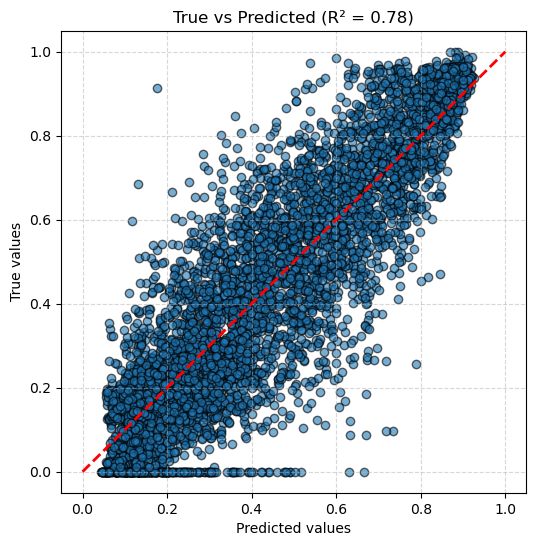

0.7842385159985648

In [2]:
l1, l2, l3, l4, l5 = 6, 3, 11, 7, 3
levels_list = [l1, l2, l3, l4, l5]
lambdas_list=[1e-4,5e-4,1e-3, 1e-2] ## AIC selected

shim = SHIM(X=X_all,
            y=y_all,
            init_list=None,
            levels_list=levels_list,
            lambdas_list=list(lambdas_list),
            max_iter=3,
            use_init_main = False,
            use_init_main_w= False,
            w_list=None
        )

shim_fitted = shim.fit_model()
shim_fitted.R2_score(X_all, y_all, plot=True)



# Recover the coefficicents with identifiability conditions and save them


In [3]:
beta_all_shim=shim_fitted.model.beta_all
intercept_all=shim_fitted.model.intercept

print(f"Number of non-zeros in fitted coefficients  is: {sum(beta_all_shim!=0)+1} out of {len(beta_all_shim)+1} coefficients.")

coefs_all = np.concatenate(([intercept_all], beta_all_shim))


recovered_coefs=recover_coefs_with_names(main_names=main_names, beta= beta_all_shim, intercept=intercept_all, levels=levels_list)
recovered_coefs.loc[recovered_coefs.index.isin(nan_names), "Values"] = np.nan
print(f"Number of non-zeros in recovered coefficients  is: {((recovered_coefs["Values"] != 0) & (~recovered_coefs["Values"].isna())).sum()} out of {(~recovered_coefs["Values"].isna()).sum()} coefficients.")

recovered_coefs.to_excel("Final_coefficients_Suzuki.xlsx")
print("The final coefficients are saved in Analysis_Suzuki_Miyaura folder.")


Number of non-zeros in fitted coefficients  is: 211 out of 6594 coefficients.
Number of non-zeros in recovered coefficients  is: 419 out of 10035 coefficients.
The final coefficients are saved in Analysis_Suzuki_Miyaura folder.
